<h1>Table of Contents</h1>
<ol>
    <li><a href="#introduction">Introduction</a></li>
    <li><a href="#setup">Setup</a>
        <ul>
            <li><a href="#colab">Running the notebook in Colab</a></li>
            <li><a href="#import-libraries">Import required libraries</a></li>
        </ul>
    </li>
    <li><a href="#data-access">Data access, download and pre-processing</a>
        <ul>
            <li><a href="#upload-laz">Option 1: Upload your own point cloud files</a></li>
            <li><a href="#upload-dem">Option 2: Upload your own DEMs</a></li>
            <li><a href="#download-laz">Option 3: Download point clouds using OpenTopography API</a></li>
            <li><a href="#upload-download-mix">Option 4: Upload one file and download another</a></li>
        </ul>
    </li>
    <li><a href="#visualization">Visualization and Derived Rasters</a>
        <ul>
            <li><a href="#plot-dems">Plot the DEMs</a></li>
            <li><a href="#hillshade">Hillshade</a></li>
            <li><a href="#slope">Slope</a></li>
            <li><a href="#aspect">Aspect</a></li>
            <li><a href="#roughness">Roughness</a></li>
        </ul>
    </li>
    <li><a href="#differencing">Differencing</a></li>
    <li><a href="#error-analysis">Error Analysis</a>
        <ul>
            <li><a href="#define-stable-areas">Define stable areas</a></li>
            <li><a href="#descriptive-stats">Descriptive Statistics</a></li>
            <li><a href="#estimate-error">Estimate systematic error</a></li>
        </ul>
    </li>
</ol>
                                               

<h1><a id="introduction"></a>1. Introduction</h1>

Vertical topographic differencing is a powerful technique for quantifying landscape change by comparing digital elevation models (DEMs) from different time periods. This notebook provides a comprehensive workflow for performing this analysis, with a strong emphasis on robustly quantifying the associated uncertainty. The methods implemented here are designed to identify and model various error components, including systematic bias and spatially correlated errors, which can otherwise obscure real topographic signals. The core of this workflow is a geostatistical approach that uses variogram analysis to characterize the spatial structure of error, allowing for a more nuanced and accurate assessment of topographic change than traditional methods.

The primary goal of this notebook is to provide a step-by-step guide for users to apply these methods to their own data. The analysis is broken down into several key steps:

* **Data Loading:** Importing the necessary point clouds, DEMs and metadata.
* **Topographic Differencing:** Calculating the difference between the DEMs.
* **Stable/Unstable Area Identification:** Delineating areas that are assumed to be unchanged between surveys to assess the survey-to-survey error.
* **Uncertainty Analysis:** Using variography to model the spatial structure of the error and generate mean uncertainty estimates.

<h2><a id="setup"></a>2. Setup</h2>

<h3><a id="colab"></a>Running the notebook in Colab</h3>

For ease-of-use, it is suggested to launch and execute these notebooks on <a href="https://colab.research.google.com/">Google Colaboratory</a> (Colab, for short), Google's Cloud Platform. Dependencies will be installed on a virtual machine on Google's cloud servers and the code will be executed directly in your browser. A major benefit of this is that you will have direct access to Google's high-end CPU/GPUs and will not have to install any dependencies locally. All deliverables will be saved to your personal Google Drive. To experiment and run one of the below Jupyter Notebooks on Google Colab click the "Open in Colab" badge below.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cassandra-Brigham/topographic-difference-uncertainty/blob/main/my_implementation.ipynb)

In [1]:
# Colab setup check
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print(f"Running in Colab with Python {sys.version}")
else:
    print("Not running in Colab")

Not running in Colab


In [2]:
import os, sys, pathlib

# --- Colab guard ---
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # 1) Mount Drive (idempotent)
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    # 2) Check if condacolab is already fully configured
    # We verify both that conda exists AND that LD_LIBRARY_PATH is set
    conda_ready = (
        os.path.exists("/usr/local/bin/conda") and
        "LD_LIBRARY_PATH" in os.environ
    )
    
    if conda_ready:
        import condacolab
        condacolab.check()
        print("✓ Condacolab already installed and configured")
    else:
        print("Installing condacolab (kernel will restart)...")
        !pip install -q condacolab
        import condacolab
        condacolab.install()  # This restarts the kernel
else:
    print("Not running in Colab; skipping condacolab setup.")

Not running in Colab; skipping condacolab setup.


**⚠️ Kernel Restart Required**

If this is your first time running this notebook, the cell above will have installed `condacolab` and **automatically restarted the kernel**. This is expected behavior.

**Please proceed by running the cell below** to continue with the environment setup. The next cell will install PDAL and the remaining dependencies.

In [3]:
import os, sys, pathlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Verify condacolab and install PDAL
    import condacolab
    condacolab.check()
    
    # Remove conflicting Python pin and install PDAL
    !rm -f /usr/local/conda-meta/pinned
    !mamba install -y -c conda-forge pdal python-pdal
    
    # Fix SQLite symlink - conda installs newer SQLite but old symlink remains
    # Dynamically find the installed SQLite version instead of hardcoding
    !sqlite_lib=$(ls /usr/local/lib/libsqlite3.so.3.* 2>/dev/null | head -1) && \
        if [ -n "$sqlite_lib" ]; then \
            sudo ln -sf "$sqlite_lib" /usr/local/lib/libsqlite3.so.0; \
            echo "Linked $sqlite_lib -> libsqlite3.so.0"; \
        fi
    
    # Fix numpy version conflict
    !{sys.executable} -m pip install -q "numpy<2.2"
    
    # Set PROJ environment
    os.environ['PROJ_LIB'] = '/usr/local/share/proj/'
    
    # Install topochange from GitHub
    print("\nInstalling topochange package...")
    !{sys.executable} -m pip install -q --no-cache-dir git+https://github.com/Cassandra-Brigham/topochange.git
    
    # Install additional packages not in topochange dependencies
    !{sys.executable} -m pip install -q small-gicp colormaps boto3
    
    # Verify PDAL via wrapper
    from topochange.pdal_wrapper import pdal, get_pdal_status
    status = get_pdal_status()
    print(f"\nEnvironment ready!")
    print(f"  PDAL version: {status['version']}")
    print(f"  PDAL mode: {status['mode']}")
else:
    print("Not running in Colab; skipping environment setup.")

Not running in Colab; skipping environment setup.


In [4]:
# Install visualization libraries
%pip install -q comm ipywidgets
%pip install -q ipyleaflet

# Fix pyproj PROJ path (Colab-specific, may need adjustment based on conda installation)
import os
import sys

# Set PROJ_LIB if needed (conda usually handles this automatically)
if IN_COLAB and not os.environ.get("PROJ_LIB"):
    from google.colab import output
    output.enable_custom_widget_manager()
    # Try common conda locations first
    possible_proj_paths = [
        "/opt/conda/share/proj",
        "/usr/share/proj", 
        "/usr/local/share/proj"
    ]
    for proj_path in possible_proj_paths:
        if os.path.isdir(proj_path):
            os.environ["PROJ_LIB"] = proj_path
            break

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
# API Key Setup

# Try to get OPENTOPO_API_KEY from multiple sources:
# 1. Colab Secrets (most secure for Colab users)
# 2. Environment variable (works locally and in Colab)
# 3. Manual setting (fallback)

api_key = None

if IN_COLAB:
    # Try Colab secrets first (recommended for Colab users)
    try:
        from google.colab import userdata
        api_key = userdata.get('OPENTOPOGRAPHY_API_KEY')
        print("✓ Using OPENTOPOGRAPHY_API_KEY from Colab secrets")
    except Exception:
        # Fall back to environment variable
        api_key = os.getenv('OPENTOPOGRAPHY_API_KEY')
        if api_key:
            print("✓ Using OPENTOPOGRAPHY_API_KEY from environment variable")
        else:
            print("⚠️  OPENTOPOGRAPHY_API_KEY not found!")
            print("   Option 1 (Recommended): Add to Colab secrets via the 🔑 icon in left sidebar")
            print("   Option 2: Run this in a cell: os.environ['OPENTOPO_API_KEY'] = 'your_key_here'")
            print("   Get your key at: https://portal.opentopography.org/requestService")
else:
    # Local environment - use environment variable
    api_key = os.getenv('OPENTOPOGRAPHY_API_KEY')
    if api_key:
        print("✓ Using OPENTOPOGRAPHY_API_KEY from environment variable")
    else:
        print("⚠️  OPENTOPOGRAPHY_API_KEY not found in environment variables")
        print("   Set it in your shell before running Jupyter, or run:")
        print("   os.environ['OPENTOPOGRAPHY_API_KEY'] = 'your_key_here'")
# Set the environment variable if we found a key
if api_key:
    os.environ['OPENTOPOGRAPHY_API_KEY'] = api_key

✓ Using OPENTOPOGRAPHY_API_KEY from environment variable


#### Set your data path here!

In [ ]:
# - Colab users: Update COLAB_DATA_DIR to point to your Google Drive data folder
# - Local users: Update LOCAL_DATA_DIR to point to your local data folder
# Verify that the path is correct in the next cell.

if IN_COLAB:
  # Google Drive data directory (update this to your actual data location, e.g., "/content/drive/MyDrive/Research/topographic-data").
  COLAB_DATA_DIR = "/content/drive/MyDrive/topographic-differencing-data/philly" #/content/drive/MyDrive/path/to/your/folder"
else:
  # Local data directory (update this to your local path)
  LOCAL_DATA_DIR = "/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/test_data/test_dems" #"/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/test_data"


In [7]:
if IN_COLAB:
    BASE_DATA_DIR = Path(COLAB_DATA_DIR)
    
    print(f"Using Colab data directory: {BASE_DATA_DIR}")
else:
    BASE_DATA_DIR = Path(LOCAL_DATA_DIR)
    
    print(f"Using local data directory: {BASE_DATA_DIR}")

# Create base directory if it doesn't exist
BASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to resolve data paths
def get_data_path(*path_parts):
    return str(BASE_DATA_DIR / Path(*path_parts))

Using local data directory: /Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/test_data/test_dems


<h3><a id="import-libraries"></a>Import required libraries</h3>

This cell imports the necessary Python libraries for data handling and analysis, including custom functions from the provided scripts for differencing, variography, and stable area analysis.

In [8]:
# Install topochange from GitHub

import sys
import colormaps as cmaps
import os
import numpy as np
import importlib
import rasterio

# Core classes (always available)
from topochange import (
    Raster,
    RasterPair,
    PointCloud,
    PointCloudPair,
    CRSHistory,
    CRSState,
    build_vertical_pipeline,
    VariogramAnalysis,
    RasterDataHandler,
    StatisticalAnalysis,
    RegionalUncertaintyEstimator,
)

# Interactive features (requires ipyleaflet)
from topochange import (
    TopoMapInteractor,
    StableAreaRasterizer,
    StableAreaAnalyzer,
)

# CRS utilities
from topochange.crs_utils import (
    crs_to_projjson,
    _ensure_crs_obj,
    crs_to_wkt2_2019,
    wrap_coordinate_metadata_wkt,
    make_coordinate_metadata_projjson,
    transformer_with_epoch,
)

# Geoid utilities
from topochange.geoid_utils import (
    _iter_text_fields,
    _search_patterns,
    _from_json_vertical,
    parse_geoid_info,
    list_proj_geoid_grids,
    _norm,
    _matches_alias,
    select_geoid_grid,
    ensure_proj_grid,
    ensure_proj_grids_for_region,
    get_all_proj_data_dirs,
)

# Time utilities
from topochange.time_utils import (
    _gps_leap_seconds,
    _datetime_to_decimal_year,
    gps_seconds_to_decimal_year_utc,
    _guess_in_time_from_stats,
)

# Pipeline builder
from topochange.pipeline_builder import build_complete_pipeline

# Velocity model registry
from topochange.velocity_model_registry import (
    VelocityModelInfo,
    load_registry,
    find_model_file,
)

# Deformation utilities
from topochange.deformation_utils import select_velocity_model

# Alignment
from topochange.alignment import (
    RegistrationMethod,
    DownsamplingMethod,
    RegistrationConfig,
    PointCloudProcessor,
    RegistrationResult,
    LandscapeAligner,
    PointCloudPairAligner,
    quick_align,
    robust_align,
)

# Data access (requires ipyleaflet and osgeo - optional)
try:
    from topochange import data_access
    from topochange.data_access import (
        DataAccess,
        OpenTopographyQuery,
        GetDEMs,
    )
except ImportError as e:
    print(f"Note: Data access module not available ({e})")
    data_access = None
    DataAccess = None
    OpenTopographyQuery = None
    GetDEMs = None

# Stable area analysis (requires ipyleaflet - optional)
try:
    from topochange.stable_area_analysis import descriptive_stats
except ImportError as e:
    print(f"Note: descriptive_stats not available ({e})")
    descriptive_stats = None

SEED = 42

# ============================================================
# Ensure PROJ geoid grids are available (works in Colab & locally)
# ============================================================
if IN_COLAB:
    print("Setting up PROJ geoid grids for Colab...")
    print(f"PROJ data directories: {get_all_proj_data_dirs()}")
    
    # Ensure common US NOAA geoid grids are available
    ensure_proj_grids_for_region('us_noaa', verbose=True)
    
    print("\nPROJ geoid grids ready")

<h1><a id="data-access"></a>Data access, download and pre-processing</h1>

This section outlines four options for loading your compare (older) and reference (newer) topographic datasets. [cite_start]The pre-processing steps ensure that both datasets are aligned to a common coordinate reference system (CRS), grid, and vertical datum, which is essential for accurate differencing[cite: 66, 109].

<h2><a id="upload-laz"></a>Option 1: Upload your own point cloud files</h2>

Use this option if you have local `.las` or `.laz` point cloud files. The code will generate Digital Terrain Models (DTMs) and Digital Surface Models (DSMs) from your data and then align them.

In [9]:
# Define point cloud file paths

compare_pc_path = get_data_path("compare.laz")
reference_pc_path = get_data_path("reference.laz")

<h3><a id="extract_metadata"></a>Extract metadata from point cloud file</h3>


- Input format: use a point cloud in .las or .laz format.
- The path to the compare point cloud is already set in compare_pc_path.
- In the next cells, a PointCloud object (pc1) is created from compare_pc_path, its metadata is read from the file header/VLRs, and then printed for review.
- This step only inspects metadata (CRS, vertical datum/geoid, epoch, units, scales/offsets, bounds, classifications, returns, GPS time type); it does not modify the data.
- If key fields are missing or incorrect (e.g., compound CRS, horizontal/vertical CRS, geoid model, epoch), the following sections demonstrate how to update them using add_metadata before creating DEMs or performing transformations.

In [10]:
# Create PointCloud object and read in metadata
pc1 = PointCloud(compare_pc_path)
pc1.from_file()

In [11]:
pc1.print_metadata()


--- CRS Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Compound CRS              COMPD_CS["NAD83 / UTM zone 11N + NAVD88 height",
Horizontal CRS            PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DAT
Vertical CRS              VERT_CS["NAVD88 height",VERT_DATUM["North Americ
Geoid model               None

--- Point Cloud Metadata ---
Property                  Value                                             
---------------------------------------------------------------------------
Total points              10,201,715
Bounds                    (211445.84, 3759782.27, 212363.74, 3760504.68)
Horizontal units          metre (m) (EPSG:9001)
Vertical units            metre (m) (EPSG:9001)

--- Time Information ---
Property                  Value                                             
--------------------------------------------------------------------------

<h3><a id="update_metadata"></a>Update point cloud metadata</h3>



Sometimes the file will lack important metadata or the metadata will be parsed incorrectly. To remedy this, we can manually update the point cloud metadata if we know more information.


In [ ]:
# Complete these fields if known, comment out if unknown

# GEOID_COMPARE = None # e.g., "geoid12b"
# EPOCH_COMPARE = "05/18/2005 - 05/27/2005"
# HORIZ_CRS_COMPARE = None # e.g., "32611" 
# VERT_CRS_COMPARE = None # e.g., "5703" 
# COMPLETE_CRS_COMPARE = "4979" # e.g., "EPSG:3136+EPSG:5703"

# GEOID_REFERENCE = "geoid12b"
# EPOCH_REFERENCE = "05/27/2018 - 07/22/2018"
# HORIZ_CRS_REFERENCE = None # e.g., "32611" 
# VERT_CRS_REFERENCE = "5703" 
# COMPLETE_CRS_REFERENCE = None # e.g., "EPSG:3136+EPSG:5703"

# GEOID_COMPARE = "geoid09" 
# EPOCH_COMPARE = " 03/11/2010 - 04/08/2010"
# HORIZ_CRS_COMPARE = "26911"
# VERT_CRS_COMPARE =   "5703" # "North American Vertical Datum of 1988 (NAVD88)"
# COMPLETE_CRS_COMPARE = None

# GEOID_REFERENCE = "geoid18"
# EPOCH_REFERENCE = "12/02/2023 - 12/07/2023"
# HORIZ_CRS_REFERENCE = "32610"
# VERT_CRS_REFERENCE = "5703" # "North American Vertical Datum of 1988 (NAVD88)"
# COMPLETE_CRS_REFERENCE = None

GEOID_COMPARE = "geoid18" 
EPOCH_COMPARE = "03/21/2006 - 05/10/2008"
HORIZ_CRS_COMPARE = "3748"
VERT_CRS_COMPARE =   "5703" # "North American Vertical Datum of 1988 (NAVD88)"
COMPLETE_CRS_COMPARE = None

GEOID_REFERENCE = "geoid18"
EPOCH_REFERENCE = "04/12/2015 - 05/23/2015"
HORIZ_CRS_REFERENCE = "6347"
VERT_CRS_REFERENCE = "5703" # "North American Vertical Datum of 1988 (NAVD88)"
COMPLETE_CRS_REFERENCE = None

<h4><a id="update_compound"></a>Update compound Coordinate Reference System</h4>

In [13]:
# Update compound CRS, using either a PROJ string, a WKT string, or an EPSG code.
# Skip this step if you are sure the compound CRS is correct

# If compound CRS is wrong or missing, can update metadata manually
  
if COMPLETE_CRS_COMPARE:
    pc1.add_metadata(compound_CRS=COMPLETE_CRS_COMPARE)
else:
    pass
print(f"Original compound CRS: {pc1.original_compound_crs}")  
print(f"Updated compound CRS: {pc1.current_compound_crs}")

Original compound CRS: COMPD_CS["NAD83 / UTM zone 11N + NAVD88 height",PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5703"]]]
Updated compound CRS: COMPD_CS["NAD83 / UTM zone 11N + NAVD88 height",PROJCS["NAD83 / UTM zone 11N",GEOGCS[

<h4><a id="update_horiz"></a>Update horizontal Coordinate Reference System</h4>

In [14]:
# Update horizontal CRS, using either a PROJ string, a WKT string, or an EPSG code.
# Skip this step if you are sure the horizontal CRS is correct.

if HORIZ_CRS_COMPARE:
    pc1.add_metadata(horizontal_CRS=HORIZ_CRS_COMPARE)
else:
    pass

print ("Original horizontal CRS:", pc1.original_horizontal_crs)
print("Original compound CRS:", pc1.original_compound_crs)
print("")
print(f"Updated horizontal CRS: {pc1.current_horizontal_crs}")
print(f"Updated compound CRS : {pc1.current_compound_crs}")

Original horizontal CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]]
Original compound CRS: COMPD_CS["NAD83 / UTM zone 11N + NAVD88 height",PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORIT

<h4><a id="update_vertical"></a>Update vertical Coordinate Reference System</h4>

In [15]:
# Update vertical CRS, using either a PROJ string, a WKT string, or an EPSG code.

# Skip this step if you are sure the vertical CRS is correct.

if VERT_CRS_COMPARE:
    pc1.add_metadata(vertical_CRS=VERT_CRS_COMPARE)
else:
    pass

print ("Original vertical CRS:", pc1.original_vertical_crs)
print("Original compound CRS:", pc1.original_compound_crs)
print("")
print(f"Updated vertical CRS: {pc1.current_vertical_crs}")
print(f"Updated compound CRS : {pc1.current_compound_crs}")

Original vertical CRS: VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5703"]]
Original compound CRS: COMPD_CS["NAD83 / UTM zone 11N + NAVD88 height",PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORIT

<h4><a id="update_geoid"></a>Update geoid</h4>

In [16]:
# If vertical coordinates are orthometric and geoid is wrong or missing, can update metadata manually
print(f"Original geoid model: \n {pc1.geoid_model}")
print(f"Original vertical CRS: \n {pc1.current_vertical_crs}")
print(f"Are the vertical coordinates orthometric?  \n {pc1.is_orthometric}")

Original geoid model: 
 None
Original vertical CRS: 
 VERTCRS["NAVD88 height",VDATUM["North American Vertical Datum 1988"],CS[vertical,1],AXIS["gravity-related height (H)",up,LENGTHUNIT["metre",1]],USAGE[SCOPE["Geodesy, engineering survey, topographic mapping."],AREA["Mexico - onshore. United States (USA) - CONUS and Alaska - onshore - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming."],BBOX[14.51,172.42,71.4,-66.91]],ID["EPSG",5703]]
Are the vertical coordinates orthometric?  
 True


In [17]:
# Update geoid, using either a PROJ string, a WKT string, or an EPSG code.
if GEOID_COMPARE:
    geoid_grid, _ =select_geoid_grid(GEOID_COMPARE,verbose=True)
    
    # If the automatic selection is not the desired grid, you can specify the index of your desired grid in the list of matches. Uncomment the lines below and set choice to the desired index.
    #geoid_grid_2, _ =select_geoid_grid(geoid, choice=1)
    #print(f"Select the second grid: {geoid_grid_2}")
    
    pc1.add_metadata(geoid_model=geoid_grid)
else:
    pass

print(f"Geoid model: {pc1.geoid_model}")
print(f"Vertical CRS:{pc1.current_vertical_crs}")
print(f"Are the vertical coordinates orthometric? {pc1.is_orthometric}")

Geoid grids for 'geoid09' (canonical 'geoid09'):
  [0] us_noaa_geoid09_conus.tif (local)  <== selected (auto-selected local u0/CONUS grid)
  [1] us_noaa_g2009g01.tif (local)
  [2] us_noaa_g2009h01.tif (local)
  [3] us_noaa_g2009p01.tif (local)
  [4] us_noaa_g2009s01.tif (local)
  [5] us_noaa_geoid09_ak.tif (local)
  [6] us_noaa_geoid09_conus.tif (local)
Geoid model: us_noaa_geoid09_conus.tif
Vertical CRS:VERTCRS["NAVD88 height",VDATUM["North American Vertical Datum 1988"],CS[vertical,1],AXIS["gravity-related height (H)",up,LENGTHUNIT["metre",1]],USAGE[SCOPE["Geodesy, engineering survey, topographic mapping."],AREA["Mexico - onshore. United States (USA) - CONUS and Alaska - onshore - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New Yo


<h4><a id="update_epoch"></a>Update epoch</h4>

Accurate epoch metadata is critical when working with time-dependent coordinate reference systems and transformations.

- Many modern CRSs (e.g., ITRF, NAD83(2011), WGS84 realizations) are defined at a specific epoch and use velocities to propagate coordinates through time. Without the correct epoch, transformation pipelines cannot apply the right motion, leading to offsets.
- Horizontal positions can drift several centimeters per year due to tectonic motion; over a decade this can reach decimeter-level errors. Vertical biases can be similar or larger in areas with subsidence or uplift.
- When aligning point clouds to reference datasets collected at different times, mismatched epochs cause systematic misalignment that looks like a rigid shift or tilt rather than random noise.
- Velocity/deformation models and time-dependent Helmert transforms require an epoch to compute displacement; defaults (or missing epoch) often introduce hidden biases.
- Correct epoch improves repeatability, change detection, and metadata transparency, ensuring others can reproduce transformations and understand residuals.
- If data were collected over a range of dates, using the midpoint as the epoch is a practical, documented approximation for most transformations.

In [18]:
# If epoch is wrong or missing, can update metadata
print(f"Original epoch: {pc1.epoch}")

Original epoch: 2010.2197919488838


In [19]:
if EPOCH_COMPARE:
    # Update epoch, using either a decimal year, a single date, or a date range (the epoch will be set to the midpoint of the date range)
    pc1.add_metadata(epoch=EPOCH_COMPARE)
else:
    pass

print(f"Updated epoch: {pc1.epoch}")

Updated epoch: 2010.2273972602738


In [20]:
# Final check of all metadata
print("Current compound CRS:", pc1.current_compound_crs)
print("Current horizontal CRS:", pc1.current_horizontal_crs)
print("Current vertical CRS:", pc1.current_vertical_crs)
print("Current geoid model:", pc1.geoid_model)
print("Current epoch:", pc1.epoch)

Current compound CRS: COMPOUNDCRS["NAD83 / UTM zone 11N + NAVD88 height",PROJCRS["NAD83 / UTM zone 11N",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4269]],CONVERSION["UTM zone 11N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-117,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["(E)",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["(N)",north,ORDER[2],LENGTHUNIT["metre",1]],USAGE[SCOPE["Engineering survey, topographic mapping."],AREA["North America - between

<h3><a id="import_ref_cloud"></a>Import reference point cloud</h3>

In [21]:
# Create PointCloud object and read in metadata
pc2 = PointCloud(reference_pc_path)
pc2.from_file()

In [22]:
pc2.print_metadata()


--- CRS Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Compound CRS              PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",D
Horizontal CRS            PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",D
Vertical CRS              
Geoid model               None

--- Point Cloud Metadata ---
Property                  Value                                             
---------------------------------------------------------------------------
Total points              8,410,115
Bounds                    (766004.2719, 3759150.361, 766920.3631, 3759870.544)
Horizontal units          metre (m) (EPSG:9001)
Vertical units            unknown (?)

--- Time Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Creation year             2026
Creation DOY        

In [23]:
pc2.add_metadata(
    horizontal_CRS=HORIZ_CRS_REFERENCE if HORIZ_CRS_REFERENCE else None,
    vertical_CRS=VERT_CRS_REFERENCE if VERT_CRS_REFERENCE else None,
    compound_CRS=COMPLETE_CRS_REFERENCE if COMPLETE_CRS_REFERENCE else None,
    geoid_model=GEOID_REFERENCE if GEOID_REFERENCE else None,
    epoch=EPOCH_REFERENCE if EPOCH_REFERENCE else None,
                 )

In [24]:
print("Current compound CRS:", pc2.current_compound_crs)
print("Current horizontal CRS:", pc2.current_horizontal_crs)
print("Current vertical CRS:", pc2.current_vertical_crs)
print("Current geoid model:", pc2.geoid_model)
print("Current epoch:", pc2.epoch)


Current compound CRS: COMPOUNDCRS["WGS 84 / UTM zone 10N + NAVD88 height",PROJCRS["WGS 84 / UTM zone 10N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natu

<h3><a id="warp_cloud"></a>Reproject point clouds</h3>

In [25]:
pc_pair = PointCloudPair(pc1,pc2)

In [26]:
# Check what needs transformation
pc_pair.print_comparison()



--- PointCloudPair Comparison ---

Compare (pc1):   compare.laz
Reference (pc2): reference.laz

Parameter            Match    PC1                  PC2                 
----------------------------------------------------------------------
Horizontal CRS       No       EPSG:26911           EPSG:32610          
Vertical CRS         Yes      Orthometric          Orthometric         
Geoid Model          No       us_noaa_geoid09_co.. us_noaa_g2018u0.tif 
Epoch                No       2010.2274            2023.9247           
Vertical Units       Yes      meter                meter               
----------------------------------------------------------------------

Transformations needed: horizontal_crs, vertical_datum, epoch



In [27]:
# Transform. If epochs differ, this may take some time. You can skip epoch transformation for faster processing if needed:
# # Skip epoch for faster iteration during development
transformed = pc_pair.transform_compare_to_match_reference(
    skip_epoch=True,  # Skip the slow part
    verbose=True,
    
)
#transformed = pc_pair.transform_compare_to_match_reference() 


--- Transform compare to match reference ---
Transformations needed: ['horizontal_crs', 'vertical_datum', 'epoch']
  Vertical: orthometric -> orthometric
  Geoid: us_noaa_geoid09_conus.tif -> us_noaa_g2018u0.tif
  Horizontal CRS reprojection needed
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
  Combined transformation [done]

Output: /Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/test_data/test_dems/compare_orth_reproj.laz


In [28]:
# For alignment with memory constraints, use larger voxel sizes:
align_result = pc_pair.align_point_clouds(
    method="vgicp",
    downsample_resolution=1.0,      # Larger = fewer points (default 0.5)
    initial_voxel_size=2.0,         # Larger = more aggressive initial downsampling
    max_points=1_000_000,           # Limit max points (default 2M)
)


--- Point Cloud Alignment (small_gicp) ---
Method: VGICP
Downsample resolution: 1.0 m
Max correspondence distance: 1.0 m
Initial voxel downsampling: 2.0 m
Max points per cloud: 1,000,000

Loading source points from: compare_orth_reproj.laz
Loading target points from: reference.laz
Source points: 281,203
Target points: 268,664

Centering point clouds (centroid: [766456.1, 3759508.9, 411.2])
Source range after centering: X=958.0, Y=774.0, Z=686.0
Target range after centering: X=916.0, Y=720.0, Z=226.0
XY overlap region: 916.0 x 720.0 m

Point data check:
  Source dtype: float64, shape: (281203, 3)
  Target dtype: float64, shape: (268664, 3)
  Source sample: [[-472.40732341  332.62018055  -40.59990143]
 [-472.40732341  334.62018055  -40.59990143]
 [-470.40732341  332.62018055  -40.59990143]]
  Target sample: [[191.19267659 330.11018055  47.65009857]
 [191.19267659 332.11018055  47.65009857]
 [189.19267659 330.11018055  47.65009857]]

Running VGICP registration...
  downsample_resolution:

In [29]:
# Create DEMs

output_dir = get_data_path("dem_output")
os.makedirs(output_dir, exist_ok=True)
dem1, dem2 = pc_pair.create_dtm_pair(resolution=1.0, output_dir=output_dir)


Creating DTM pair
Resolution: 1.0 m
Interpolation: idw

Creating DEM from pc1: compare_orth_reproj_aligned.laz


/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Creating DEM from pc2: reference.laz

DEM1: /Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/test_data/test_dems/dem_output/compare_orth_reproj_aligned_dtm_1m.tif
DEM2: /Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/test_data/test_dems/dem_output/reference_dtm_1m.tif



In [30]:
# Check vertical and horizontal units
print("dem1 horizontal_unit:", dem1.horizontal_unit)
print("dem1 vertical_unit:", dem1.vertical_unit)

print("dem2 horizontal_unit:", dem2.horizontal_unit)
print("dem2 vertical_unit:", dem2.vertical_unit)

dem1 horizontal_unit: metre (m)
dem1 vertical_unit: unknown (?)
dem2 horizontal_unit: metre (m)
dem2 vertical_unit: unknown (?)


In [31]:
# Set units if info is missing
dem1.set_units(vertical_unit="meter")
print("dem1 vertical_unit:", dem1.vertical_unit)

dem2.set_units(vertical_unit="meter")
print("dem2 vertical_unit:", dem2.vertical_unit)

dem1 vertical_unit: metre (m)
dem2 vertical_unit: metre (m)



--- Computing Difference (raster2 - raster1) ---

--- Raster Transformation ---
Step                           Status                        
------------------------------------------------------------
Grid alignment                 [done]
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
------------------------------------------------------------

Source       Valid Pixels         Percent   
------------------------------------------
Raster1           643,727 / 661,157   97.4%
Raster2           627,871 / 661,157   95.0%
Overlap           626,654 / 661,157   94.8%

--- Difference Statistics ---
Statistic    Value (m)      
---------------------------
Min               -4.9274
Max  

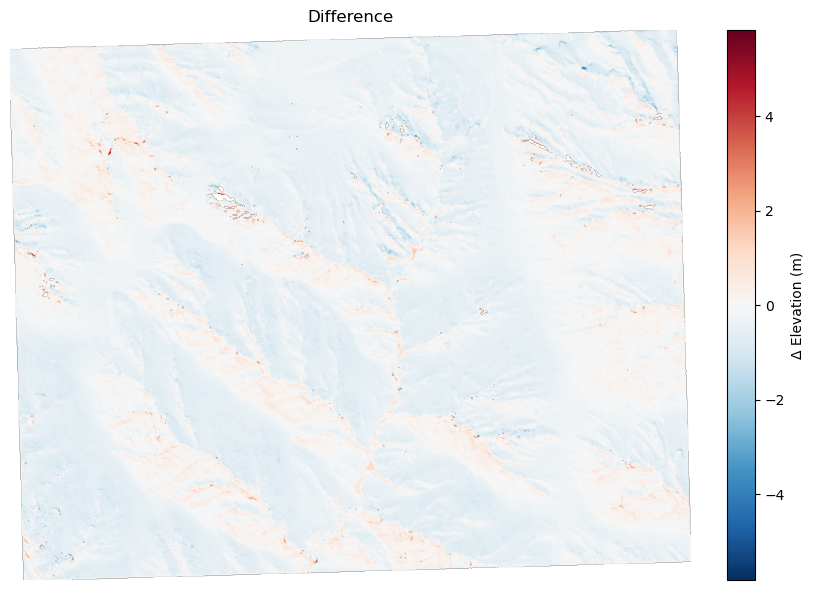

In [32]:
# Compute difference
pair = RasterPair(dem1, dem2)
output_dir = get_data_path("dem_output")
os.makedirs(output_dir, exist_ok=True)

result = pair.compute_difference(
    skip_epoch=True,
    interpolation_method="bilinear",
    clip_to_overlap=True,
    output_path=os.path.join(output_dir, "difference.tif"),
    verbose=True
)

# Plot
fig = pair.plot_difference()

<h2><a id="upload-dem"></a>Option 2: Upload your own DEMs</h2>

If you already have DEM files (e.g., GeoTIFFs), use this option. The code will ensure they are aligned before proceeding.

In [33]:
# Define paths to your DEM files (GeoTIFF format)
# Update these paths as needed to match your input data

dem1_path = get_data_path("compare.tif")  # Earlier time period
dem2_path = get_data_path("reference.tif")  # Later time period

In [34]:
# Load DEMs using the Raster class
dem1 = Raster.from_file(dem1_path)

dem2 = Raster.from_file(dem2_path)

print(f"DEM1 shape: {dem1.shape}")
print(f"DEM1: Resolution: {dem1.resolution}")
print(f"DEM1: Original compound CRS: {dem1.original_compound_crs}")
print(f"DEM1: Original horizontal CRS: {dem1.original_horizontal_crs}")
print(f"DEM1: Original vertical CRS: {dem1.original_vertical_crs}")
print(f"DEM1: Full CRS: {dem1.original_full_crs}")
print(f"DEM1: Geoid model: {dem1.current_geoid_model}")

print(f"DEM2 shape: {dem2.shape}")
print(f"DEM2: Resolution: {dem2.resolution}")
print(f"DEM2: Original compound CRS: {dem2.original_compound_crs}")
print(f"DEM2: Original horizontal CRS: {dem2.original_horizontal_crs}")
print(f"DEM2: Original vertical CRS: {dem2.original_vertical_crs}")
print(f"DEM2: Full CRS: {dem2.original_full_crs}")
print(f"DEM2: Geoid model: {dem2.current_geoid_model}")


DEM1 shape: (723, 919)
DEM1: Resolution: 1.0
DEM1: Original compound CRS: None
DEM1: Original horizontal CRS: PROJCRS["NAD83 / UTM zone 11N",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4269]],CONVERSION["UTM zone 11N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-117,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",26911]]
DEM1: Original ver

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


<h3><a id="update_metadata"></a>Update raster metadata</h3>

In [35]:
# Complete these fields if known, comment out if unknown

GEOID_COMPARE = None # e.g., "geoid12b"
EPOCH_COMPARE = None # e.g., "05/18/2005 - 05/27/2005" or "05/01/2016" or 
HORIZ_CRS_COMPARE = None # e.g., "32611" 
VERT_CRS_COMPARE =  None# e.g., "5703" 
COMPLETE_CRS_COMPARE = None# e.g., "EPSG:3136+EPSG:5703" or "4979"

GEOID_REFERENCE = "geoid12b"
EPOCH_REFERENCE = "05/27/2018 - 07/22/2018"
HORIZ_CRS_REFERENCE = 32611 # e.g., "32611" 
VERT_CRS_REFERENCE = "5703" 
COMPLETE_CRS_REFERENCE = None # e.g., "EPSG:3136+EPSG:5703"


<h4><a id="update_compound_raster"></a>Update compound Coordinate Reference System</h4>

In [36]:
# Check compare DEM metadata
print("Original compound CRS:", dem1.original_compound_crs)
print("Original horizontal CRS:", dem1.original_horizontal_crs)
print("Original vertical CRS:", dem1.original_vertical_crs)
print("Original geoid model:", dem1.original_geoid_model)
print("Original epoch:", dem1.epoch)

Original compound CRS: None
Original horizontal CRS: PROJCRS["NAD83 / UTM zone 11N",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4269]],CONVERSION["UTM zone 11N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-117,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",26911]]
Original vertical CRS: None
Original geoid model: None
Original epoch: None

In [37]:
dem1.add_metadata(
    horizontal_CRS=HORIZ_CRS_COMPARE if HORIZ_CRS_COMPARE else None,
    vertical_CRS=VERT_CRS_COMPARE if VERT_CRS_COMPARE else None,
    compound_CRS=COMPLETE_CRS_COMPARE if COMPLETE_CRS_COMPARE else None,
    geoid_model=GEOID_COMPARE if GEOID_COMPARE else None,
    epoch=EPOCH_COMPARE if EPOCH_COMPARE else None,
                 )

In [38]:
# Final check of compare DEM metadata
print("Current compound CRS:", dem1.current_compound_crs)
print("Current horizontal CRS:", dem1.current_horizontal_crs)
print("Current vertical CRS:", dem1.current_vertical_crs)
print("Current geoid model:", dem1.current_geoid_model)
print("Current epoch:", dem1.epoch)

Current compound CRS: None
Current horizontal CRS: PROJCRS["NAD83 / UTM zone 11N",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4269]],CONVERSION["UTM zone 11N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-117,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",26911]]
Current vertical CRS: None
Current geoid model: None
Current epoch: None


In [39]:
# Check reference DEM metadata
print("Original compound CRS:", dem2.original_compound_crs)
print("Original horizontal CRS:", dem2.original_horizontal_crs)
print("Original vertical CRS:", dem2.original_vertical_crs)
print("Original geoid model:", dem2.original_geoid_model)
print("Original epoch:", dem2.epoch)

Original compound CRS: None
Original horizontal CRS: PROJCRS["WGS 84 / UTM zone 10N",BASEGEOGCRS["WGS 84",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",32610]]
Original vertical CRS: None
Original geoid model: None
Original epoch: None


In [40]:
dem2.add_metadata(
    horizontal_CRS=HORIZ_CRS_REFERENCE if HORIZ_CRS_REFERENCE else None,
    vertical_CRS=VERT_CRS_REFERENCE if VERT_CRS_REFERENCE else None,
    compound_CRS=COMPLETE_CRS_REFERENCE if COMPLETE_CRS_REFERENCE else None,
    geoid_model=GEOID_REFERENCE if GEOID_REFERENCE else None,
    epoch=EPOCH_REFERENCE if EPOCH_REFERENCE else None,
                 )

In [41]:
# Final check of reference DEM metadata
print("Current compound CRS:", dem2.current_compound_crs)
print("Current horizontal CRS:", dem2.current_horizontal_crs)
print("Current vertical CRS:", dem2.current_vertical_crs)
print("Current geoid model:", dem2.current_geoid_model)
print("Current epoch:", dem2.epoch)

Current compound CRS: COMPOUNDCRS["WGS 84 / UTM zone 11N + NAVD88 height",PROJCRS["WGS 84 / UTM zone 11N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 11N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-117,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natu

<h3><a id="transform-raster"></a>Raster transformations</h3>


--- Computing Difference (raster2 - raster1) ---

--- Raster Transformation ---
Step                           Status                        
------------------------------------------------------------
Horizontal reprojection        EPSG:26911 -> EPSG:32611


dem1 vertical_unit: metre (m)


/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
Vertical datum                 ellipsoidal -> orthometric
Geoid model                    None -> us_noaa_g2012bu0.tif
Grid alignment                 [done]
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
------------------------------------------------------------

Source       Valid Pixels         Percent   
-----------------------

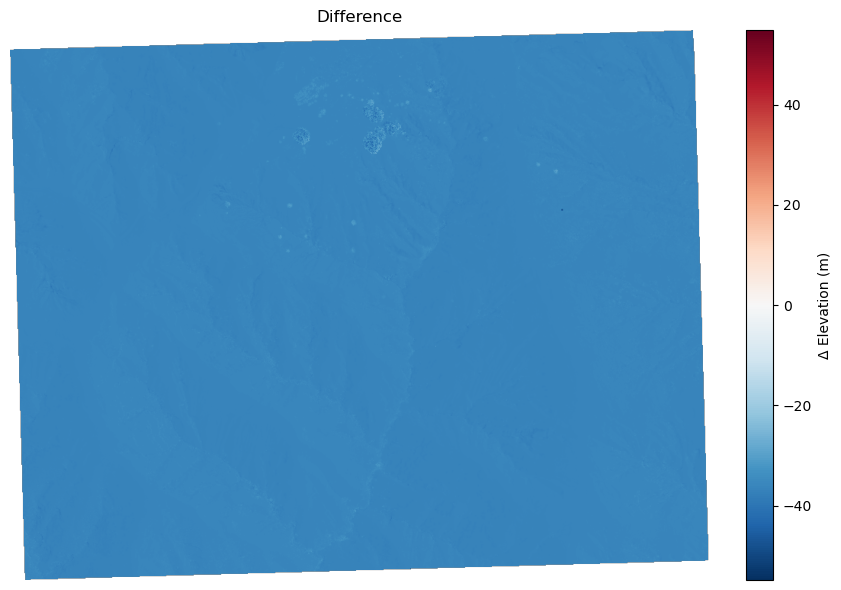

In [42]:
# Set units
dem1.set_units(vertical_unit="meter")
print("dem1 vertical_unit:", dem1.vertical_unit)

# Compute difference
output_dir = Path.joinpath(BASE_DATA_DIR,"dem_output")
pair = RasterPair(dem1, dem2)
if IN_COLAB:
    import os
    os.makedirs(output_dir, exist_ok=True)
    result = pair.compute_difference(
        skip_epoch=True,
        interpolation_method="bilinear",
        clip_to_overlap=True,
        output_path=str(output_dir / "difference.tif"),
        verbose=True
    )
else:
    result = pair.compute_difference(
        skip_epoch=True,
        interpolation_method="bilinear",
        clip_to_overlap=True,
        verbose=True
    )

# Plot
fig = pair.plot_difference()

<h2><a id="download-laz"></a>Option 3: Download point clouds using OpenTopography API</h2>

This option allows you to define an area of interest (AOI), search the OpenTopography data catalog for available datasets, and download the point clouds to generate DEMs.

<h3><a id="api-key"></a>Finding and storing your API Key</h3>


We recommend storing your OT API key in a environment variable. This prevents keys from being hardcoded in the source code, reducing the risk of exposure through sharing or version control. It also enhances flexibility, allowing the same code to be used in various environments without changes. Below are the steps to take to store your API key in an environment variable.  

<h4><a id="Linux-macOS"></a>For Linux/macOS</h4>

Open up a Terminal window and find your shell's profile script. For Bash, you might find '~ /.bashrc' or '~ /.bash_profile'.
For Zsh, you might find '~ /.zshrc'.  

```cd ~```  
```ls -a```  

Once you know the name of your shell's profile script, you can edit it using a text editor that operates in the terminal (like ```nano``` or ```vim```) or out side the terminal with the text editor of your choosing. This example will use '~/.zshrc' as the name of the shell profile script and ```nano``` as the text editor. If the file is read-only, you might need to use ```sudo``` to edit it.  

```nano ~/.zshrc```  

At the end of the .zshrc file, add a line to define your environment variable. 'your_api_key_here' is a stand in for the alphanumeric API key accessible at [MyOpenTopo](https://portal.opentopography.org/myopentopo) under "Get an API Key."   
 
```export OPENTOPOGRAPHY_API_KEY='your_api_key_here'```


Exit (```control + X``` for ```nano```) and save (```Y``` to ```Save modified buffer (ANSWERING "No" WILL DESTROY CHANGES) ?``` then ```Enter``` for ```nano```).

For your changes to take effect, you need to reload the .zshrc file or restart your terminal. To reload .zshrc without restarting, type the following command in your terminal and press Enter:  

```source ~/.zshrc```  

This will make the OPENTOPOGRAPHY_API_KEY environment variable available in all new terminal sessions.  

<h4><a id="Windows"></a>For Windows</h4> 

1. Search for "Environment Variables" in the Start menu.
1. Click on "Edit the system environment variables."
1. In the System Properties window, click on "Environment Variables."
1. Click on "New" under System variables or User variables depending on your need.
1. Set "Variable name" as OPENTOPOGRAPHY_API_KEY and "Variable value" as your actual API key. Your alphanumeric API key is accessible at [MyOpenTopo](https://portal.opentopography.org/myopentopo) under "Get an API Key."
1. Click OK and apply the changes.

<h4><a id="Google-Colab"></a>For Google Colab</h4>

Google Colab provides a built-in "Secrets" feature that securely stores sensitive information like API keys. This is the recommended approach because your key won't be visible in your notebook or saved in your notebook's history.

1. Open your notebook in Google Colab.
2. Click the **key icon** (🔑) in the left sidebar to open the "Secrets" panel.
3. Click **"Add new secret"**.
4. In the "Name" field, enter: `OPENTOPOGRAPHY_API_KEY`
5. In the "Value" field, paste your API key. Your alphanumeric API key is accessible at [MyOpenTopo](https://portal.opentopography.org/myopentopo) under "Get an API Key."
6. Toggle the **"Notebook access"** switch to allow this notebook to access the secret.
7. Click the checkmark to save.

To use the secret in your code, you'll access it through Colab's `userdata` module:

```python
from google.colab import userdata
API_Key = userdata.get('OPENTOPOGRAPHY_API_KEY')
```

**Note:** Secrets are stored in your Google account and persist across sessions, so you only need to set this up once. However, you must enable "Notebook access" for each new notebook that needs the key.

<h3><a id="Load-API-Key"></a>Load API key</h3>


In [43]:
# After setting the environment variable, access your API key in this notebook.
API_Key = os.getenv("OPENTOPOGRAPHY_API_KEY")

# If your API key is not set correctly, you can set it manually here. Be careful about sharing the notebook if your API key is visible.
#API_Key = "your_api_key_here"

if API_Key is not None:
    print("API Key loaded successfully!")
else:
    print("Failed to load API Key.")

API Key loaded successfully!


<h3><a id="Define-AOI"></a>Define area of interest</h3>

To specify the geographic region for your dataset search, you have three options. You can 1) manually enter latitude and longitude bounds if you know the exact coordinates of your area of interest; 2) upload a shapefile or GEOJSON to automatically populate the same extent variables; 3) draw a bounding box directly on the interactive map embedded in this notebook: simply click and drag to sketch the rectangle around your target area, and the notebook captures both the corner coordinates and the equivalent WKT polygon for your API queries.

<h4><a id="Option-1-Draw-Map"></a>Option 1: Draw a bounding box on an interactive map</h4>

In [44]:
da = DataAccess()
da.init_ot_catalog_map(zoom=3)

Map(center=[39.8283, -98.5795], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…

In [45]:
da.bounds

{}

<h4><a id="Option-2-Manual-Bounds"></a> Option 2: Define bounds manually</h4>

In [46]:
da = DataAccess()
south = 38.953619
north = 38.953827
west =  -104.926257
east = -104.925967
da.define_bounds_manual(south, north, west, east)

{'south': 38.953619,
 'north': 38.953827,
 'west': -104.926257,
 'east': -104.925967,
 'polygon_wkt': ['-104.925967, 38.953619, -104.925967, 38.953827, -104.926257, 38.953827, -104.926257, 38.953619, -104.925967, 38.953619']}

<h4><a id="Option-3-Upload-File"></a> Option 3: Define bounds using an uploaded file</h4>

In [47]:
# Define shapefile path for bounds
# Update this path to match your shapefile location
if IN_COLAB:
    # In Colab, update this to your shapefile location in Google Drive
    shapefile_path = get_data_path("bounds/bounds.shp")
else:
    # Local path - update as needed
    shapefile_path = "path/to/your/shapefile.shp"

da = DataAccess()
da.define_bounds_from_file(shapefile_path, target_crs='EPSG:4326')

DataSourceError: path/to/your/shapefile.shp: No such file or directory

<h3><a id="Use-OT-Catalog-comp-ref"></a> Use OT Catalog To Find Paired Compare/Reference Datasets</h3>

This section uses OpenTopography’s `otCatalog` API endpoint to perform a bounding‐box search of available datasets within the area of interest defined above. 

In [ ]:
# Initialize the OpenTopography query object with our DataAccess instance
otq = OpenTopographyQuery(da)

otq.query_catalog(
    product_format="PointCloud",    # only return point cloud products; use "Raster" or omit to get all
    include_federated=True,         # include external catalogs (e.g. USGS 3DEP) via OpenTopography
    detail=False,                   # set to True for full metadata; False returns summary fields
    save_as="results.json"          # save raw JSON response to this file for inspection or reuse
)

# Show the first few rows of the catalog dataframe
otq.catalog_df

<h4><a id="Select-Compare-Ref"></a> Select compare/reference datasets for differencing</h4>

In [ ]:
# choose the indices of the desired reference and compare datasets 
compare_index   = 0   # Older/pre-event dataset
reference_index = 1   # Younger/post-event dataset

# now tell the query object which ones to use as which
otq.pick(compare_index, reference_index)

In [ ]:
compare_meta = otq.get_metadata_dict("compare")
compare_meta

In [ ]:
reference_meta = otq.get_metadata_dict("reference")
reference_meta

<h3><a id="Get-DEMs"></a> Download topographic data and interpolate Digital Elevation Models </h3>

In [ ]:
# Initialize the DEM interpolation/download object with our DataAccess and OpenTopographyQuery instances
gdems = GetDEMs(da, otq)

# Folder where downloaded DEMs and intermediate files will be saved
folder = get_data_path("dem_output")
os.makedirs(folder, exist_ok=True)

# Base name for output files (DEM files will be named like "output_name" + "_compare_DTM.tif", etc.)
output_name = "ot_differencing"

gdems.set_compare_units(f'{otq.get_metadata_dict("compare").get("vertical_units")}')
gdems.set_reference_units(f'{otq.get_metadata_dict("reference").get("vertical_units")}')

# If the vertical units are missing or incorrect in the metadata, you can set them manually here. Uncomment these lines and set the correct units:

# gdems.set_compare_units(f'us_survey_foot') # foot, meter, etc.
# gdems.set_reference_units(f'us_survey_foot')

In [ ]:
gdems.dem_download_workflow(
        folder,
        output_name,
        API_Key,                           
        dem_resolution = 1.0,           
        dataset_type = "compare",
        epoch = otq.compare_epoch,           
        filterNoise = True,             
        reclassify = False,         
        savePointCloud = True,         
        pc_resolution = 0.1,            
        outCRS = "WGS84 UTM",
        method="idw",                  
        nodata=-9999,                   
        max_dist=50,                   
        smooth_iter=0                   
    )           
    

gdems.dem_download_workflow(
        folder,
        output_name,
        API_Key,
        dem_resolution = 1.0,
        dataset_type = "reference",
        epoch = otq.reference_epoch,  
        filterNoise = True,
        reclassify = False,
        savePointCloud = True,
        pc_resolution = 0.1,            
        outCRS = "WGS84 UTM",   
        method="idw",                  
        nodata=-9999,                   
        max_dist=50,                   
        smooth_iter=0                   
    ) 

In [ ]:
pair = gdems.get_dtm_pair()
pair.print_summary()

In [ ]:
output_dir = get_data_path("dem_output")
os.makedirs(output_dir, exist_ok=True)

result = pair.compute_difference(
    skip_epoch=True,
    interpolation_method="bilinear",
    clip_to_overlap=True,
    output_path=os.path.join(output_dir, "difference.tif"),
    verbose=True
)

<h1><a id="visualization"></a>Visualization and Derived Rasters</h1>

This section focuses on visualizing the results and creating derived topographic products like hillshades and slope maps, which are useful for interpreting the observed changes[cite: 206].

<h2><a id="plot-dems"></a>Plot the DEMs and derive</h2>

In [ ]:
# Generate derivatives for both rasters
hillshade1, hillshade2 = pair.generate_derivative("hillshade")
slope1, slope2 = pair.generate_derivative("slope")
aspect1, aspect2 = pair.generate_derivative("aspect")
roughness1, roughness2 = pair.generate_derivative("roughness")

# Plot side-by-side with automatic derivative generation
fig, axes = pair.plot_pair(derivative='dem')        # Original DEMs
fig, axes = pair.plot_pair(derivative='hillshade')  # Hillshades
fig, axes = pair.plot_pair(derivative='slope')      # Slopes
fig, axes = pair.plot_pair(derivative='aspect')     # Aspects
fig, axes = pair.plot_pair(derivative='roughness')  # Roughness

# Customize hillshade parameters
fig, axes = pair.plot_pair(
    derivative='hillshade',
    azimuth=270,    # West-facing light
    altitude=30,    # Low sun angle
    figsize=(14, 6)
)

In [ ]:
pair.plot_difference()

<h1><a id="error-analysis"></a>Error Analysis</h1>

<h2><a id="define-stable-areas"></a>Define stable areas</h2>

A key part of this workflow is the use of **stable areas**—regions where no topographic change is expected—to characterize the error between the two surveys. The elevation differences within these areas are used to model the uncertainty.

Use the interactive map below to draw polygons over areas you consider stable (e.g., roads, bedrock outcrops, undisturbed ground).

**Instructions:**
1. Use the polygon tool to draw areas of no expected change
2. Select "Stable" from the layer dropdown when drawing
3. Run the cells below after drawing your polygons

In [ ]:
diff = result.get("difference_raster")

In [ ]:
out_folder_poly = Path.joinpath(BASE_DATA_DIR,"polygons/")
os.makedirs(out_folder_poly, exist_ok=True)


interactor = TopoMapInteractor(
    topo_diff_path=diff.filename,
    hillshade_path=hillshade1.filename,
    output_dir=out_folder_poly,
    overlay_dpi=600,
    overlay_vmin=-2,
    overlay_vmax=2,
)

interactor.map

In [ ]:
interactor.stable_geoms

In [ ]:
interactor.unstable_geoms

<h2><a id="descriptive-stats"></a>Descriptive Statistics</h2>

In [ ]:
stable_polys, _ = interactor.export_geodataframes()

# one combined mask
rasterizer_stable = StableAreaRasterizer(interactor.topo_diff.path, stable_polys, nodata=-9999)
analyzer_stable = StableAreaAnalyzer(rasterizer_stable)

# Combined-area stats
df_all_stable_polys = analyzer_stable.stats_all(Path.joinpath(BASE_DATA_DIR,"polygons/combined_stable.tif"))

# Per-area stats
df_each_stable_poly = analyzer_stable.stats_each(Path.joinpath(BASE_DATA_DIR,"polygons/each_stable/"))


In [ ]:
df_all_stable_polys

In [ ]:
df_each_stable_poly

<h2><a id="estimate-error"></a>Estimate systematic error</h2>

In [ ]:

# Load the stable area raster (this is the masked difference raster)
stable_area_path = Path.joinpath(BASE_DATA_DIR, "polygons/combined_stable.tif")
stable_area = Raster.from_file(stable_area_path)

# Get the median from the stable area
# Read the data directly with rasterio to get valid values

with rasterio.open(stable_area_path) as src:
    data = src.read(1)
    nodata = src.nodata
    # Mask nodata values
    if nodata is not None:
        valid_data = data[data != nodata]
    else:
        valid_data = data[np.isfinite(data)]
    
    diff_stable_median = np.median(valid_data)
    print(f"Median of stable area differences: {diff_stable_median:.4f} m")

# Set up paths and parameters
output_path = Path.joinpath(BASE_DATA_DIR, "polygons/combined_stable_bias_removed.tif")
unit = "m"
dem_resolution = 1.0

# Load raster data using RasterDataHandler
raster_data_handler = RasterDataHandler(stable_area_path, unit, dem_resolution)
raster_data_handler.load_raster()

# Get the data array
vert_diff_array = raster_data_handler.data_array

# Measure of vertical bias (median)
vertical_bias = np.median(vert_diff_array)
print(f"Vertical bias: {vertical_bias:.4f} m")

# Get uncertainty in the median value by bootstrap resampling
stats = StatisticalAnalysis(raster_data_handler)
median_uncertainty = stats.bootstrap_uncertainty_subsample(n_bootstrap=1000, subsample_proportion=0.1)
print(f"Median uncertainty (bootstrap): {median_uncertainty:.4f} m")

# Subtract the vertical bias from the stable area raster and save
raster_data_handler.subtract_value_from_raster(output_path, vertical_bias)
print(f"Saved bias-removed raster to: {output_path}")

# Create new RasterDataHandler for the modified raster
raster_bias_removed = RasterDataHandler(output_path, unit, dem_resolution)
raster_bias_removed.load_raster()

print(f"\nBias-removed stats:")
print(f"  Mean: {np.mean(raster_bias_removed.data_array):.4f} m")
print(f"  Median: {np.median(raster_bias_removed.data_array):.4f} m")
print(f"  Std: {np.std(raster_bias_removed.data_array):.4f} m")

In [ ]:
fig = stats.plot_data_stats()

<h2><a id="Variography"></a>Variography</h2>

This section uses the stable areas defined above to perform the geostatistical analysis. An experimental variogram is calculated from the DoD values within the stable areas, and then a mathematical model (nested spherical) is fitted to it. This model captures the spatial correlation of the error, which is then used to propagate uncertainty across the entire study area[cite: 113, 127].

In [ ]:
#Create variogram analysis instance based on modified raster
V = VariogramAnalysis(raster_bias_removed)

#Calculate a mean variogram with 75 bins from variograms made over 10 runs
V.calculate_mean_variogram_numba(area_side = 250, samples_per_area = 400, max_samples = 1000000000, bin_width = 30, max_n_bins = 3000, n_runs = 30, max_lag_multiplier = 0.5)

In [ ]:
BOUNDS = None

V.fit_best_spherical_model(sigma_type='std', bounds=BOUNDS, seed=SEED)

In [ ]:
fig = V.plot_best_spherical_model()

<h2><a id="Total mean error"></a>Total mean error</h2>

### Draw unstable (change) areas

Use the interactive map below to draw polygons around areas where you expect topographic change (e.g., landslides, construction sites, eroded channels). These "unstable" areas will be used to calculate uncertainty estimates for the regions of interest.

**Instructions:**
1. Use the polygon tool to draw areas of expected change
2. Select "Unstable" from the layer dropdown when drawing
3. Run the cells below after drawing your polygons

In [ ]:
interactor.map

In [ ]:
interactor.unstable_geoms

In [ ]:
_, unstable_polys = interactor.export_geodataframes()

In [ ]:
uncertainties_per_feature_of_interest = []
for i, poly in enumerate(unstable_polys['geometry']):
    uncertainty_temp = RegionalUncertaintyEstimator(raster_bias_removed, V, area_of_interest=poly)
    uncertainty_temp.calc_mean_uncertainty(n_pairs=25_000, seed=SEED, sigma_func=None)
    uncertainties_per_feature_of_interest.append(uncertainty_temp)

total_mean_uncertainty_raster = uncertainties_per_feature_of_interest[0].total_mean_uncertainty_raster
total_mean_uncertainty_min_raster = uncertainties_per_feature_of_interest[0].total_mean_uncertainty_min_raster
total_mean_uncertainty_max_raster = uncertainties_per_feature_of_interest[0].total_mean_uncertainty_max_raster

mean_random_uncorrelated_raster = uncertainties_per_feature_of_interest[0].mean_random_uncorrelated_raster

total_mean_correlated_uncertainties_polygon = []
total_mean_correlated_uncertainties_polygon_min = []
total_mean_correlated_uncertainties_polygon_max = []

total_mean_uncorrelated_uncertainties_polygon = []

total_mean_uncertainties_polygon = []
total_mean_uncertainty_min_polygon = []
total_mean_uncertainty_max_polygon = []

for uncertainty in uncertainties_per_feature_of_interest:
    mean_correlated_uncertainty_polygon = uncertainty.total_mean_correlated_uncertainty_polygon
    mean_correlated_uncertainty_min_polygon = uncertainty.total_mean_correlated_uncertainty_min_polygon
    mean_correlated_uncertainty_max_polygon = uncertainty.total_mean_correlated_uncertainty_max_polygon
    
    mean_uncertainty_polygon = uncertainty.total_mean_uncertainty_polygon
    mean_uncertainty_min_polygon = uncertainty.total_mean_uncertainty_min_polygon
    mean_uncertainty_max_polygon = uncertainty.total_mean_uncertainty_max_polygon
    
    mean_random_uncorrelated = uncertainty.mean_random_uncorrelated
    
    total_mean_correlated_uncertainties_polygon.append(mean_correlated_uncertainty_polygon)
    total_mean_correlated_uncertainties_polygon_min.append(mean_correlated_uncertainty_min_polygon)
    total_mean_correlated_uncertainties_polygon_max.append(mean_correlated_uncertainty_max_polygon)
    
    total_mean_uncorrelated_uncertainties_polygon.append(mean_random_uncorrelated)
    
    total_mean_uncertainties_polygon.append(mean_uncertainty_polygon)
    total_mean_uncertainty_min_polygon.append(mean_uncertainty_min_polygon)
    total_mean_uncertainty_max_polygon.append(mean_uncertainty_max_polygon)


    

In [ ]:
# Summary of uncertainty estimates per polygon
print("=" * 70)
print("UNCERTAINTY SUMMARY PER FEATURE OF INTEREST")
print("=" * 70)

for i in range(len(uncertainties_per_feature_of_interest)):
    print(f"\nPolygon {i + 1}:")
    print(f"  Correlated uncertainty:   {total_mean_correlated_uncertainties_polygon[i]:.4f} m "
          f"[{total_mean_correlated_uncertainties_polygon_min[i]:.4f}, "
          f"{total_mean_correlated_uncertainties_polygon_max[i]:.4f}]")
    print(f"  Uncorrelated uncertainty: {total_mean_uncorrelated_uncertainties_polygon[i]:.4f} m")
    print(f"  Total uncertainty:        {total_mean_uncertainties_polygon[i]:.4f} m "
          f"[{total_mean_uncertainty_min_polygon[i]:.4f}, "
          f"{total_mean_uncertainty_max_polygon[i]:.4f}]")

print("\n" + "=" * 70)